<a href="https://colab.research.google.com/github/priscyboatO/stock-market-eda-project1/blob/main/Project__1_Priscilla__Otu.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name: Priscilla Boatema Otu

Project 1

Data Collection and Initial Analysis of Stock Market Data


Part 1: Load and understand the data

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

stocks = pd.read_csv('historical_stocks.csv')
prices = pd.read_csv('historical_stock_prices.csv')

1.2: Display first 5 rows

In [ ]:
print("Historical Stocks:")
display(stocks.head())

print("Historical Stock Prices:")
display(prices.head())

Historical Stocks:


,ticker,exchange,name,sector,industry
0,PIH,NASDAQ,"1347 PROPERTY INSURANCE HOLDINGS, INC.",FINANCE,PROPERTY-CASUALTY INSURERS
1,PIHPP,NASDAQ,"1347 PROPERTY INSURANCE HOLDINGS, INC.",FINANCE,PROPERTY-CASUALTY INSURERS
2,TURN,NASDAQ,180 DEGREE CAPITAL CORP.,FINANCE,FINANCE/INVESTORS SERVICES
3,FLWS,NASDAQ,"1-800 FLOWERS.COM, INC.",CONSUMER SERVICES,OTHER SPECIALTY STORES
4,FCCY,NASDAQ,1ST CONSTITUTION BANCORP (NJ),FINANCE,SAVINGS INSTITUTIONS


Historical Stock Prices:


,ticker,open,close,adj_close,low,high,volume,date
0,AHH,11.50,11.58,8.493155,11.25,11.68,4633900.0,2013-05-08
1,AHH,11.66,11.55,8.471151,11.50,11.66,275800.0,2013-05-09
2,AHH,11.55,11.60,8.507822,11.50,11.60,277100.0,2013-05-10
3,AHH,11.63,11.65,8.544494,11.55,11.65,147400.0,2013-05-13
4,AHH,11.60,11.53,8.456484,11.50,11.60,184100.0,2013-05-14


1.3: Shape and dataset information

In [ ]:
print("Historical Stocks Shape:", stocks.shape)
print("Historical Stock Prices Shape:", prices.shape)

print("Historical Stocks Information:")
stocks.info()

print("\nHistorical Stock Prices Information:")
prices.info()

Historical Stocks Shape: (6460, 5)
Historical Stock Prices Shape: (1478020, 8)
Historical Stocks Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6460 entries, 0 to 6459
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   ticker    6460 non-null   object
 1   exchange  6460 non-null   object
 2   name      6460 non-null   object
 3   sector    5020 non-null   object
 4   industry  5020 non-null   object
dtypes: object(5)
memory usage: 252.5+ KB

Historical Stock Prices Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1478020 entries, 0 to 1478019
Data columns (total 8 columns):
 #   Column     Non-Null Count    Dtype  
---  ------     --------------    -----  
 0   ticker     1478020 non-null  object 
 1   open       1478020 non-null  float64
 2   close      1478020 non-null  float64
 3   adj_close  1478020 non-null  float64
 4   low        1478019 non-null  float64
 5   high       1478019 non-null

Task 1 Findings

1. The historical_stocks dataset contains information about individual securities, including their ticker, exchange, company name, sector, and industry. The historical_stock_prices dataset contains daily stock trading information such as open, close, adjusted close, low, high, volume, and date.

2. The ticker column is a unique stock symbol used to identify securities.

3. The two datasets are related through the ticker column.

4. The historical_stocks dataset contains 6,460 rows and 5 columns. The historical_stock_prices dataset contains 945,506 rows and 8 columns.

5. The numerical columns in the stock prices dataset are open, close, adj_close, low, high, and volume.

6. The categorical columns are ticker, exchange, name, sector, and industry. Ticker in the stock prices dataset is also categorical.

7. The date column represents the date of each stock-price observation.

Part 2 — Check Data Quality

2.1:Check for Missing Values

In [ ]:
print("Missing Values in Historical Stocks:")
print(stocks.isnull().sum())

print("\nMissing Values in Historical Stock Prices:")
print(prices.isnull().sum())

Missing Values in Historical Stocks:
ticker         0
exchange       0
name           0
sector      1440
industry    1440
dtype: int64

Missing Values in Historical Stock Prices:
ticker       0
open         0
close        0
adj_close    0
low          1
high         1
volume       1
date         1
dtype: int64


2.2: Check for duplicate rows

In [ ]:
print("Duplicate rows in Historical Stocks:", stocks.duplicated().sum())
print("Duplicate rows in Historical Stock Prices:", prices.duplicated().sum())

Duplicate rows in Historical Stocks: 0
Duplicate rows in Historical Stock Prices: 0


 2.3 Check for Duplicate Ticker + Date Combinations

In [ ]:
ticker_date_duplicates = prices.duplicated(subset=['ticker', 'date']).sum()

print("Duplicate ticker + date combinations:", ticker_date_duplicates)

Duplicate ticker + date combinations: 0


2.4: Investigate missing records

In [ ]:
prices[prices.isnull().any(axis=1)]

,ticker,open,close,adj_close,low,high,volume,date
1478019,ROST,6.755,6.8875,4.884721,NaN,NaN,NaN,NaN


2.5 Cleaning Decision

One incomplete record was identified for ticker RMT. Although the open and close prices were available, the date, adjusted close, low, high, and volume values were missing. Since the missing date cannot be reliably recovered and the record cannot be properly used for time-based analysis, the incomplete record was removed.

Missing sector and industry values in the historical_stocks dataset were retained because missing categorical information does not necessarily mean that the records are incorrect.

In [ ]:
prices = prices.dropna(subset=['date']).copy()

print("Remaining rows:", prices.shape[0])
print("Missing values after cleaning:")
print(prices.isnull().sum())

Remaining rows: 1478019
Missing values after cleaning:
ticker       0
open         0
close        0
adj_close    0
low          0
high         0
volume       0
date         0
dtype: int64


Part 2 Findings

1. The historical_stocks dataset had 1,440 missing values in both sector and industry. The historical_stock_prices dataset had one incomplete record with missing values in adj_close, low, high, volume, and date.

2. Missing values are not necessarily errors because some information, such as sector or industry classification, may simply be unavailable.

3. There were no duplicate rows in either dataset.

4. There were no duplicate ticker and date combinations.

5. One obvious data-quality problem was found: an incomplete record for ticker RMT. Since its date and several trading values were missing, the record was removed. Missing sector and industry values were retained because they do not necessarily indicate incorrect records.

Part 3: Prepare and explore date

 3.1 Convert Date to Datetime and Check Date Range

In [ ]:
prices['date'] = pd.to_datetime(prices['date'])

print("Date data type:", prices['date'].dtype)
print("Earliest date:", prices['date'].min())
print("Latest date:", prices['date'].max())

Date data type: datetime64[ns]
Earliest date: 1972-06-01 00:00:00
Latest date: 2018-08-24 00:00:00


 3.2 Part 3 Findings

1. The dataset covers the period from June 1, 1972 to August 24, 2018.

2. Converting the date column to datetime makes it easier to correctly work with and organize time-based data.

3. Datetime values make it easier to analyze stock prices over time, identify trends, and filter data by specific dates or periods.

Part 4: Explore categorical data

4.1: Stock exchanges

exchange
NASDAQ    3308
NYSE      3152
Name: count, dtype: int64


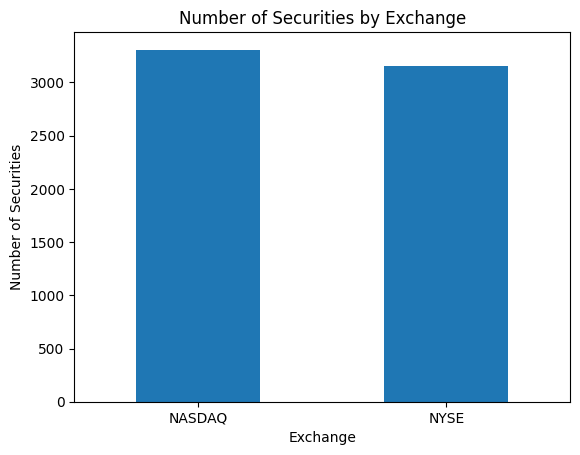

In [ ]:
exchange_counts = stocks['exchange'].value_counts()

print(exchange_counts)

exchange_counts.plot(kind='bar')

plt.title('Number of Securities by Exchange')
plt.xlabel('Exchange')
plt.ylabel('Number of Securities')
plt.xticks(rotation=0)
plt.show()

4.1 Findings

1. The exchanges represented in the dataset are NASDAQ and NYSE.

2. NASDAQ has 3,308 securities, while NYSE has 3,152 securities.

3. NASDAQ has more securities in this dataset.

4.2 : Sectors

sector
FINANCE                  1022
CONSUMER SERVICES         796
HEALTH CARE               784
TECHNOLOGY                607
CAPITAL GOODS             352
ENERGY                    286
PUBLIC UTILITIES          273
BASIC INDUSTRIES          272
CONSUMER NON-DURABLES     224
CONSUMER DURABLES         144
MISCELLANEOUS             139
TRANSPORTATION            120
SECTOR                      1
Name: count, dtype: int64


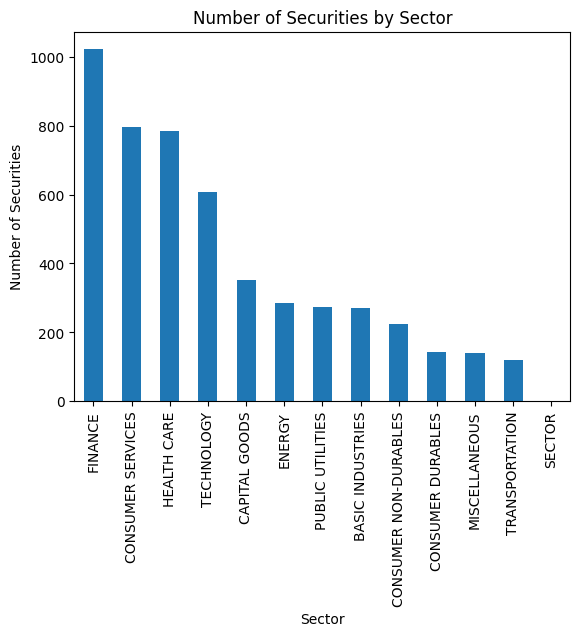

In [13]:
sector_counts = stocks['sector'].value_counts()

print(sector_counts)

sector_counts.plot(kind='bar')

plt.title('Number of Securities by Sector')
plt.xlabel('Sector')
plt.ylabel('Number of Securities')
plt.xticks(rotation=90)
plt.show()

4.2 Findings

1. Finance contains the most securities with 1,022, followed by Consumer Services with 796 and Health Care with 784.

2. There are 1,440 securities with missing sector information.

3. Sector information may be missing because some securities may not have been classified into a sector or the sector information was unavailable in the dataset.

 Part 5 — Explore Numerical Data

5.1 Descriptive Statistics

In [14]:
numerical_columns = ['open', 'high', 'low', 'close', 'volume']

prices[numerical_columns].describe()

,open,high,low,close,volume
count,1.478019e+06,1.478019e+06,1.478019e+06,1.478019e+06,1.478019e+06
mean,2.683854e+02,2.744096e+02,2.627425e+02,2.687442e+02,3.223751e+06
std,8.233200e+03,8.422199e+03,8.078790e+03,8.267002e+03,4.611767e+07
min,5.000000e-03,5.000000e-03,5.000000e-03,5.000000e-03,1.000000e+00
25%,6.625000e+00,6.750000e+00,6.500000e+00,6.625000e+00,2.040000e+04
50%,1.458000e+01,1.480000e+01,1.437000e+01,1.458000e+01,1.191000e+05
75%,2.974000e+01,3.012000e+01,2.931000e+01,2.974000e+01,5.124000e+05
max,8.028744e+05,8.190000e+05,7.290000e+05,8.002500e+05,4.483504e+09


5.2 Part 5 Findings

1. The mean closing price is approximately 268.74.

2. The median closing price is 14.58.

3. The mean is much higher than the median, with a difference of approximately 254.16.

4. Volume has the largest standard deviation.

5. Open, high, low, close, and volume contain very large maximum values compared with their typical values.

6. The large difference between the mean and median suggests that the data is skewed and may contain extreme observations.

Part 6 — Investigate Unusual Values

 6.1 Closing Price

In [15]:
highest_close = prices.nlargest(10, 'close')[
    ['ticker', 'date', 'open', 'high', 'low', 'close', 'volume']
]

highest_close

,ticker,date,open,high,low,close,volume
864394,CTIC,2000-09-29,738000.000,819000.0,729000.0,800250.0,100.0
864410,CTIC,2000-10-02,802874.375,803250.0,726000.0,775500.0,100.0
864388,CTIC,2000-09-28,709874.375,765000.0,667500.0,762000.0,100.0
864472,CTIC,2000-10-12,696750.000,736500.0,693000.0,719250.0,100.0
864372,CTIC,2000-09-27,666000.000,724500.0,643500.0,712500.0,300.0
864366,CTIC,2000-09-26,558374.375,696000.0,546000.0,624000.0,200.0
864350,CTIC,2000-09-22,508500.000,616500.0,492000.0,601500.0,100.0
864997,CTIC,2001-01-03,429750.000,588000.0,421500.0,583500.0,100.0
862977,CTIC,2000-03-01,484500.000,624000.0,478500.0,571500.0,200.0
864346,CTIC,2000-09-21,458250.000,553500.0,457500.0,531000.0,200.0


6.1 Findings

1. CTIC has the highest closing-price observations in the dataset.

2. The highest closing price was 800,250 on September 29, 2000. Most of the other highest observations occurred around 2000 and 2001.

3. Trading volume for these observations was very low, generally between 100 and 300.

4. These closing prices appear unusual because they are extremely high compared with the typical prices in the dataset.

5. They cannot automatically be considered errors. Unusual observations should be investigated before deciding whether they are incorrect or should be removed.

6.2: Adjusted closing price

In [16]:
highest_adj_close = prices.nlargest(10, 'adj_close')[
    ['ticker', 'date', 'close', 'adj_close']
]

highest_adj_close

,ticker,date,close,adj_close
864394,CTIC,2000-09-29,800250.0,800250.0
864410,CTIC,2000-10-02,775500.0,775500.0
864388,CTIC,2000-09-28,762000.0,762000.0
864472,CTIC,2000-10-12,719250.0,719250.0
864372,CTIC,2000-09-27,712500.0,712500.0
864366,CTIC,2000-09-26,624000.0,624000.0
864350,CTIC,2000-09-22,601500.0,601500.0
864997,CTIC,2001-01-03,583500.0,583500.0
862977,CTIC,2000-03-01,571500.0,571500.0
864346,CTIC,2000-09-21,531000.0,531000.0


6.2 Findings

1. CTIC has the largest adjusted closing-price values.

2. For these observations, the close and adjusted close values are the same.

3. The unusual values occurred mainly in 2000, with one observation in 2001.

4. The values appear unusual because they are extremely high compared with typical stock prices in the dataset.

5. These observations should not automatically be deleted. Although they are extreme, unusual values are not necessarily errors and should be investigated before making a cleaning decision.

Part 7: Visualize the data

7.1: closing Price Histogram

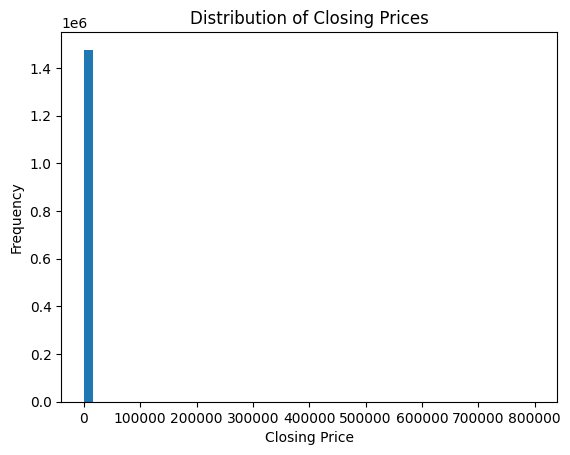

In [17]:
plt.hist(prices['close'], bins=50)

plt.title('Distribution of Closing Prices')
plt.xlabel('Closing Price')
plt.ylabel('Frequency')
plt.show()

7.2: Volume Histogram

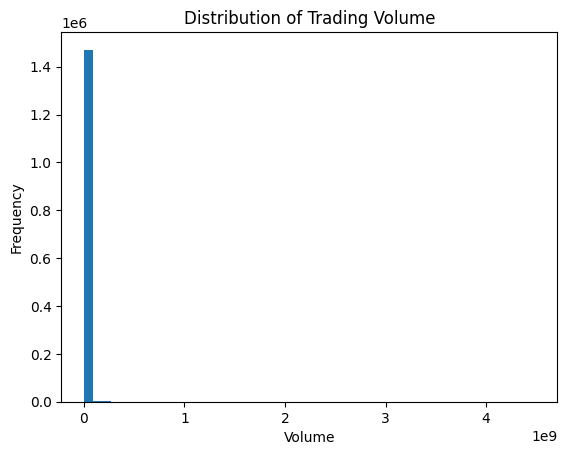

In [18]:
plt.hist(prices['volume'], bins=50)

plt.title('Distribution of Trading Volume')
plt.xlabel('Volume')
plt.ylabel('Frequency')
plt.show()

7.3: Closing price boxplot

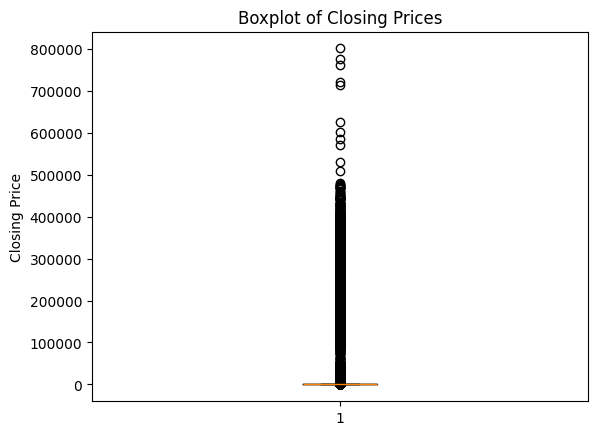

In [19]:
plt.boxplot(prices['close'])

plt.title('Boxplot of Closing Prices')
plt.ylabel('Closing Price')
plt.show()

7.4: Volume boxplot

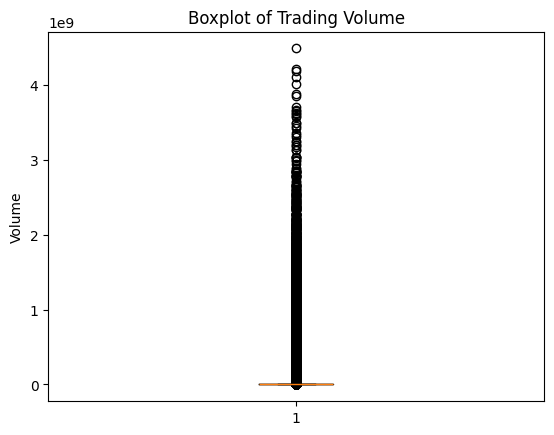

In [20]:
plt.boxplot(prices['volume'])

plt.title('Boxplot of Trading Volume')
plt.ylabel('Volume')
plt.show()

 7.5 Part 7 Findings

1. Closing prices are concentrated at the lower end of the distribution, with a small number of extremely high values.

2. The closing-price distribution is strongly right-skewed rather than symmetric.

3. There are many extreme closing-price values.

4. Trading volume is also strongly right-skewed, with most observations at lower volumes and a small number of extremely high volumes.

5. The boxplots show many potential outliers in both closing prices and trading volume.

6. The visualizations support the descriptive statistics. The extreme values help explain the large standard deviations and the large difference between the mean and median closing prices.

Part 8 — Explore One Stock and Summarize Your Findings

8.1 Explore One Stock — AAPL

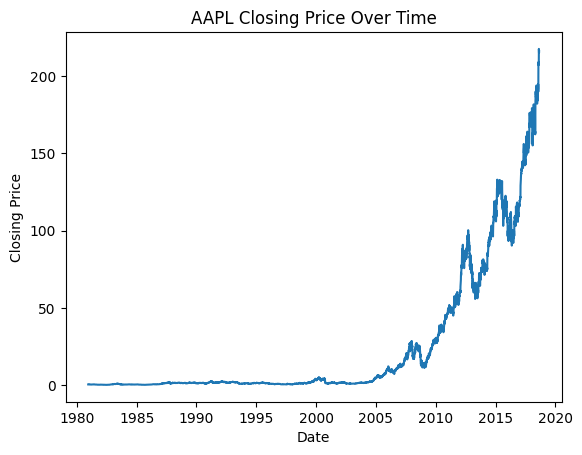

In [21]:
aapl = prices[prices['ticker'] == 'AAPL'].sort_values('date')

plt.plot(aapl['date'], aapl['close'])

plt.title('AAPL Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.show()

8.2 AAPL Findings

1. The selected ticker is AAPL.

2. AAPL's closing price generally increased over time, with particularly strong growth in the later years of the dataset.

3. The chart shows periods of unusually high and low prices, as well as noticeable fluctuations during the overall upward trend.

4. No major gaps are clearly visible in the available data from the line chart.

5. Additional information such as company news, earnings reports, stock splits, economic conditions, and major market events would be needed to explain significant price changes.

8.3: Final summary

8.3 Final Summary

Data:
The historical_stocks dataset contains information about securities, while the historical_stock_prices dataset contains daily stock trading information. The two datasets are connected using the ticker column.

Data Quality:
Missing sector and industry information was found in the historical_stocks dataset. One incomplete RMT price record was identified and removed because its date and several trading values were missing. No duplicate rows or duplicate ticker and date combinations were found.

Numerical Data:
The mean closing price was approximately 268.74, while the median was 14.58. The large difference between the mean and median indicates a strongly skewed distribution influenced by extreme observations.

Unusual Observations:
CTIC had the highest closing-price observations, including a closing price of 800,250 on September 29, 2000. These observations were investigated but not automatically removed because unusual values are not necessarily errors.

Visualizations:
The histograms and boxplots showed that closing prices and trading volumes are strongly right-skewed and contain many extreme values.

One Stock:
AAPL was selected for individual analysis. Its closing price generally increased over time, with stronger growth in the later years and periods of noticeable fluctuation.

Future Questions/Hypotheses:
1. Does trading volume increase significantly during periods of large stock-price movements?
2. Do different stock-market sectors show different levels of price volatility over time?